# cnn_models_multitask_pytorch
## Task 1 – GAN-based Image Generation  
## Task 2 – Text-to-Image Diffusion Models (Stable Diffusion)

This notebook completes the teaser part of Tutorial 1 using Google Colab:

- **Task 1:** Written analysis of GAN-based image generation (e.g., StyleGAN).
- **Task 2:** Practical generation of images using a text-to-image diffusion model (Stable Diffusion) on GPU.

The notebook combines both the conceptual explanations and the required Python code.


## Task 1 – Generative Adversarial Networks (GANs)

### 1.1. What is a GAN?

A **GAN (Generative Adversarial Network)** consists of two neural networks:

- **Generator (G):** creates synthetic images from random noise.  
- **Discriminator (D):** distinguishes real images from fake ones.

They are trained in an *adversarial* way:

- G tries to fool D.  
- D tries not to be fooled.

Mathematically, this is expressed as a minimax game:

\[
\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)]  
+ \mathbb{E}_{z \sim p(z)}[\log(1 - D(G(z)))]
\]

A well-trained GAN can generate extremely realistic images.

---

### 1.2. StyleGAN and `thispersondoesnotexist.com`

The website **thispersondoesnotexist.com** uses **StyleGAN**, a state-of-the-art GAN architecture specialized in generating **high-resolution human faces**.

When refreshing the page 10–20 times, we observe:

- Each image shows a **unique synthetic person**.
- Faces vary in:
  - age  
  - gender  
  - pose  
  - background  
  - lighting  
- The face has **high realism**, often indistinguishable from real photos.

---

### 1.3. Observed flaws and artifacts

Despite the impressive quality, careful inspection reveals artifacts:

1. **Background inconsistencies**
   - Objects or patterns appear melted or deformed.
   - Strange blending between hair and background.

2. **Accessories issues**
   - Glasses can disappear into the hair.
   - Earrings are asymmetric or floating.
   - Hats sometimes blend with the head.

3. **Facial details**
   - Teeth sometimes merge or appear irregular.
   - Ears can be oddly shaped.
   - Hair may look too smooth or unnatural.

4. **Text/logos**
   - Text is usually unreadable.
   - GANs are not good at generating typography.

These flaws highlight the **limitations** of GANs in terms of structure consistency and fine-grained details.

---

### 1.4. Other “This X Does Not Exist” GAN websites

Examples:

- **This Cat Does Not Exist** – synthetic cats  
- **This Artwork Does Not Exist** – synthetic paintings  
- **This Waifu Does Not Exist** – anime-style characters  

These examples show GANs can learn **any image distribution** given enough training data.

---

### 1.5 Summary for Task 5

- A GAN is a system of *Generator vs Discriminator*.  
- StyleGAN produces extremely realistic human faces.  
- `thispersondoesnotexist.com` is a real-world demonstration.  
- Minor flaws reveal the limits of GANs.  
- Many domains use GANs beyond human faces.


## Task 2 – Text-to-Image Diffusion Models

We now use **Google Colab with GPU** to run Stable Diffusion via the `diffusers` library.

A diffusion model generates images by:
1. Starting from pure random noise.
2. Denoising step-by-step.
3. Guiding the denoising using a text prompt.

Stable Diffusion is a **latent diffusion model**, working in a compressed latent space for efficiency.


In [1]:
!pip install diffusers transformers accelerate safetensors


In [2]:
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

# GPU check
print("CUDA available:", torch.cuda.is_available())

# Load Stable Diffusion v1.5
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    use_safetensors=True,
)

# Move model to GPU
pipe = pipe.to("cuda")

# Memory optimization
pipe.enable_attention_slicing()

print("Stable Diffusion loaded on GPU.")


CUDA available: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Stable Diffusion loaded on GPU.


### 2.2 – Example generation  
We start with the example from the tutorial:

**Prompt:**  
> "a photo of an astronaut riding a horse on mars"


Generating: a photo of an astronaut riding a horse on mars


  0%|          | 0/50 [00:00<?, ?it/s]

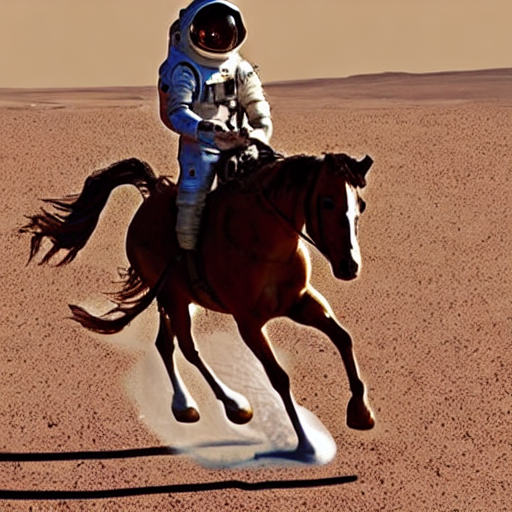

In [3]:
prompt = "a photo of an astronaut riding a horse on mars"

print(f"Generating: {prompt}")
image = pipe(prompt).images[0]
display(image)


### 2.3 – Required Prompt #1

The tutorial asks for:

> "A high-resolution photo of a cat wearing a tiny chef’s hat."




Generating: A high-resolution photo of a cat wearing a tiny chef's hat


  0%|          | 0/50 [00:00<?, ?it/s]

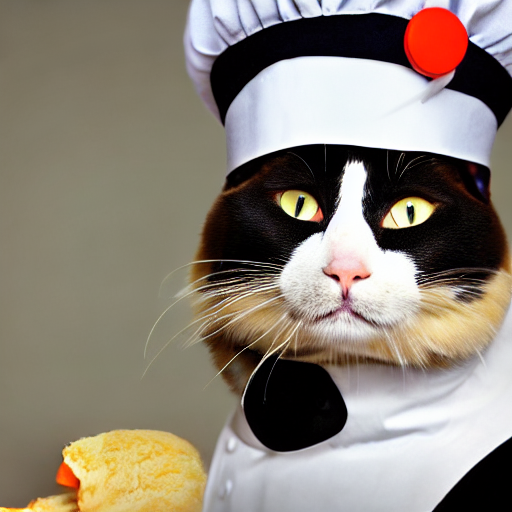

In [4]:
prompt1 = "A high-resolution photo of a cat wearing a tiny chef's hat"

print(f"Generating: {prompt1}")
image1 = pipe(prompt1).images[0]
display(image1)


### 2.4 – Required Prompt #2

> "A painting of paris in the style of Vincent van Gogh."

Generating: A painting of Paris in the style of Vincent van Gogh


  0%|          | 0/50 [00:00<?, ?it/s]

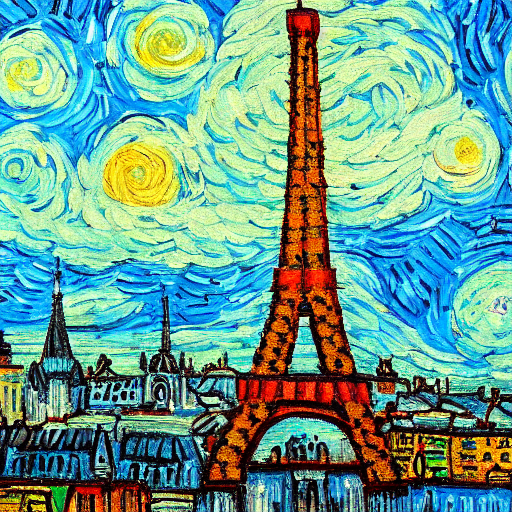

In [5]:
prompt2 = "A painting of Paris in the style of Vincent van Gogh"

print(f"Generating: {prompt2}")
image2 = pipe(prompt2).images[0]
display(image2)


## 2.5 – Analysis of the three generated images

### 1) Astronaut on horse on Mars
- Clear astronaut and horse.
- Reddish/martian background.
- Some distortions on small details (hands, helmets).

### 2) Cat with a tiny chef’s hat
- Very realistic fur and face.
- The chef hat generally appears correctly.
- Minor artifacts around the hat edges are possible.

### 3) Paris in Van Gogh style
- Strong brush strokes.
- Vibrant colors.
- Recognizable European-style architecture.
- Not always perfectly accurate for real-world Paris locations.

---

## 2.6 – Summary for Task 6

- Diffusion models denoise random noise step-by-step guided by a prompt.
- Stable Diffusion can be easily executed in Colab with GPU.
- The generated images demonstrate strong semantic alignment and artistic style control.
- Some imperfections remain, especially on text and very fine structures.

